# HW01

学号：20234080115  
姓名：李其隆


## 2 概述、线性代数和 NDArray

### 2.1 理论计算题
1. $\mathbf{a} \cdot \mathbf{b} = -8$
2. $AB = \begin{bmatrix} 8 & 5 \\ 1 & -2 \end{bmatrix}$，形状为 $(2, 2)$
3. $\|\mathbf{a}\|_F = \sqrt{14}$


In [1]:
import numpy as np

a = np.array([2, -1, 3])
b = np.array([1, 4, -2])
A = np.array([[1, 0, 2], [-1, 3, 1]])
B = np.array([[2, 1], [0, -1], [3, 2]])

print("a·b =", np.dot(a, b))
print("A @ B =\n", A @ B)
print("shape(A @ B) =", (A @ B).shape)
print("||a||_F =", np.linalg.norm(a))


a·b = -8
A @ B =
 [[ 8  5]
 [ 1 -2]]
shape(A @ B) = (2, 2)
||a||_F = 3.7416573867739413


### 2.2 编程题


In [2]:
np.random.seed(42)
X = np.random.randn(3, 4)
Y = np.ones((4, 2))
Z = X @ Y

print("X =\n", X)
print("Y =\n", Y)
print("Z = X @ Y =\n", Z)
print("Z[0, 1] =", Z[0, 1])
print("Z[1, :] =", Z[1, :])
print("||Z||_F =", np.linalg.norm(Z))


X =
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]
Y =
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Z = X @ Y =
 [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]
Z[0, 1] = 2.5291682463487657
Z[1, :] = [1.87835721 1.87835721]
||Z||_F = 4.616873319476864


## 3 文档2：概率与统计

### 3.1 理论计算题
$$
P(D|+) = \frac{0.99 \times 0.001}{0.99 \times 0.001 + 0.02 \times 0.999}
\approx 0.04721 \approx 4.72\%
$$


In [3]:
p_d = 0.001
p_pos_given_d = 0.99
p_pos_given_not_d = 0.02

p_post = (p_pos_given_d * p_d) / (p_pos_given_d * p_d + p_pos_given_not_d * (1 - p_d))
print('P(D|+) =', p_post)

P(D|+) = 0.047210300429184546


### 3.2 编程题


sample variance = 7.752783463099052e-06
theoretical variance = 8.333333333333332e-06


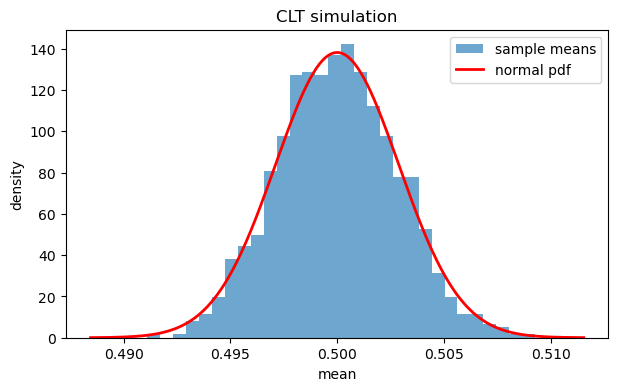

In [4]:
import matplotlib.pyplot as plt

np.random.seed(0)
n = 10000
m = 1000
samples = np.random.uniform(0, 1, size=(m, n))
means = samples.mean(axis=1)

mu = 0.5
sigma = np.sqrt((1 / 12) / n)

x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 300)
pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

plt.figure(figsize=(7, 4))
plt.hist(means, bins=30, density=True, alpha=0.65, label="sample means")
plt.plot(x, pdf, "r", lw=2, label="normal pdf")
plt.title("CLT simulation")
plt.xlabel("mean")
plt.ylabel("density")
plt.legend()
plt.show()

print("sample variance =", means.var())
print("theoretical variance =", (1 / 12) / n)


## 4 文档3：导数、反向传播和复杂度

### 4.1 理论计算题
1. $\dfrac{\partial z}{\partial w_1} = 2(w_1x_1 + w_2x_2 - y)x_1$
2. $\dfrac{\partial z}{\partial w_2} = 2(w_1x_1 + w_2x_2 - y)x_2$
3. 当 $x_1 = 2, x_2 = 1, y = 3, w_1 = 0.5, w_2 = 1$ 时，
   $\dfrac{\partial z}{\partial w_1} = -4$，$\dfrac{\partial z}{\partial w_2} = -2$


In [5]:
x1, x2, y = 2, 1, 3
w1, w2 = 0.5, 1.0
e = w1 * x1 + w2 * x2 - y
dz_dw1 = 2 * e * x1
dz_dw2 = 2 * e * x2
print('dz/dw1 =', dz_dw1)
print('dz/dw2 =', dz_dw2)

dz/dw1 = -4.0
dz/dw2 = -2.0


### 4.2 编程题


In [6]:
x, w1, w2 = 2.0, 1.5, 0.5
a = x * w1
b = a + w2
L = b ** 2
print("forward: a =", a, ", b =", b, ", L =", L)

dL_db = 2 * b
dL_dw2 = dL_db
dL_dw1 = dL_db * x
print("manual grads: dL/dw1 =", dL_dw1, ", dL/dw2 =", dL_dw2)

import torch

w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
x_t = torch.tensor(2.0)
L_t = (x_t * w1_t + w2_t) ** 2
L_t.backward()
print("autograd grads: dL/dw1 =", float(w1_t.grad), ", dL/dw2 =", float(w2_t.grad))


forward: a = 3.0 , b = 3.5 , L = 12.25
manual grads: dL/dw1 = 14.0 , dL/dw2 = 7.0
autograd grads: dL/dw1 = 14.0 , dL/dw2 = 7.0


## 5 文档4：线性方法、基础优化和 softmax 回归

### 5.1 理论计算题
$$
\frac{\partial L}{\partial w}
= \frac{2}{n} \sum_{i=1}^{n} (wx_i + b - y_i)x_i
$$
$$
\frac{\partial L}{\partial b}
= \frac{2}{n} \sum_{i=1}^{n} (wx_i + b - y_i)
$$


### 5.2 编程题


In [7]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

np.random.seed(0)

digits = load_digits()
X = digits.data.astype(np.float64) / 16.0
y = digits.target.reshape(-1, 1)

enc = OneHotEncoder(sparse_output=False)
Y = enc.fit_transform(y)

X_train, X_test, Y_train, Y_test, y_train_idx, y_test_idx = train_test_split(
    X, Y, digits.target, test_size=0.2, random_state=42, stratify=digits.target
)

n_samples, n_features = X_train.shape
n_classes = Y_train.shape[1]
W = np.zeros((n_features, n_classes))
b = np.zeros((1, n_classes))

def softmax(logits):
    z = logits - np.max(logits, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy(probs, y_onehot):
    eps = 1e-12
    return -np.mean(np.sum(y_onehot * np.log(probs + eps), axis=1))

lr = 0.1
batch_size = 32
epochs = 50

for epoch in range(epochs):
    idx = np.random.permutation(n_samples)
    X_train_shuf = X_train[idx]
    Y_train_shuf = Y_train[idx]

    for i in range(0, n_samples, batch_size):
        xb = X_train_shuf[i:i + batch_size]
        yb = Y_train_shuf[i:i + batch_size]

        logits = xb @ W + b
        probs = softmax(logits)

        grad_logits = (probs - yb) / xb.shape[0]
        grad_W = xb.T @ grad_logits
        grad_b = np.sum(grad_logits, axis=0, keepdims=True)

        W -= lr * grad_W
        b -= lr * grad_b

    if (epoch + 1) % 10 == 0:
        train_loss = cross_entropy(softmax(X_train @ W + b), Y_train)
        print(f"Epoch {epoch + 1:02d}, train loss = {train_loss:.4f}")

test_probs = softmax(X_test @ W + b)
test_pred = np.argmax(test_probs, axis=1)
test_acc = np.mean(test_pred == y_test_idx)
print("test accuracy =", test_acc)


Epoch 10, train loss = 0.4377
Epoch 20, train loss = 0.2918
Epoch 30, train loss = 0.2344
Epoch 40, train loss = 0.2023
Epoch 50, train loss = 0.1805
test accuracy = 0.9527777777777777


## 6 文档5：最大似然估计和逻辑回归

### 6.1 理论计算题
$$
L(\mu, \sigma^2) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi}\sigma}
\exp\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right)
$$
$$
\ell(\mu, \sigma^2)
= -\frac{n}{2}\log(2\pi) - n\log\sigma
- \frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2
$$
$$
\hat{\mu} = \frac{1}{n} \sum_{i=1}^{n} x_i,
\qquad
\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{\mu})^2
$$


### 6.2 编程题


Iter 0200, loss = 0.0208
Iter 0400, loss = 0.0139
Iter 0600, loss = 0.0111
Iter 0800, loss = 0.0095
Iter 1000, loss = 0.0085
test accuracy = 0.99


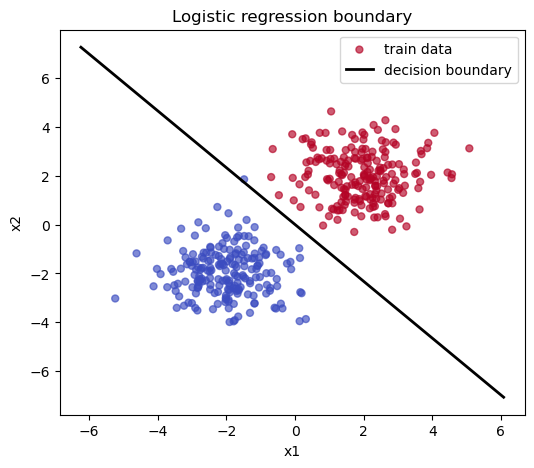

In [8]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

np.random.seed(42)

X_train, y_train = make_blobs(
    n_samples=400,
    centers=[(-2, -2), (2, 2)],
    cluster_std=1.0,
    random_state=42,
)
X_test_new, y_test_new = make_blobs(
    n_samples=100,
    centers=[(-2, -2), (2, 2)],
    cluster_std=1.0,
    random_state=123,
)

w = np.zeros((2, 1))
b = 0.0

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def bce_loss(y_true, y_prob):
    eps = 1e-12
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

lr = 0.1
iters = 1000
n_train = X_train.shape[0]
y_train_col = y_train.reshape(-1, 1)

for t in range(iters):
    logits = X_train @ w + b
    y_prob = sigmoid(logits)

    grad_w = (X_train.T @ (y_prob - y_train_col)) / n_train
    grad_b = np.mean(y_prob - y_train_col)

    w -= lr * grad_w
    b -= lr * grad_b

    if (t + 1) % 200 == 0:
        loss = bce_loss(y_train_col, y_prob)
        print(f"Iter {t + 1:04d}, loss = {loss:.4f}")

test_prob = sigmoid(X_test_new @ w + b)
test_pred = (test_prob >= 0.5).astype(int).ravel()
acc = np.mean(test_pred == y_test_new)
print("test accuracy =", acc)

plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", alpha=0.65, s=25, label="train data")

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
xx = np.linspace(x_min, x_max, 200)
if abs(w[1, 0]) > 1e-12:
    yy = -(w[0, 0] * xx + b) / w[1, 0]
    plt.plot(xx, yy, "k-", lw=2, label="decision boundary")

plt.title("Logistic regression boundary")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()
